# 02: DiD as an Interaction Regression

In a 2x2 design, DiD can be estimated with the linear model

`score = alpha + gamma * treated + delta * post + beta * treated:post + error`.

The coefficient on `treated:post` is the DiD estimate. In this
saturated 2x2 regression, the four fitted cell means exactly
reproduce the four sample cell means:

- `alpha`: control-group pre-period mean
- `gamma`: treated-control baseline difference
- `delta`: control-group time change
- `beta`: extra treated-group change after subtracting the
  control-group change


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
df = pd.read_csv(DATA_DIR / "tutoring_student_panel.csv")
print(check_columns(df, ["student_id", "school_id", "year", "treated", "post", "did", "score", "attendance", "baseline_score"]))
df.head()


Correct: all required columns are present.


,student_id,school_id,year,treated,post,did,score,attendance,baseline_score
0,S01_001,S01,2025,0,0,0,67.45,0.904,72.15
1,S01_001,S01,2026,0,1,0,71.90,0.870,72.15
2,S01_002,S01,2025,0,0,0,70.07,0.879,74.56
3,S01_002,S01,2026,0,1,0,73.29,0.867,74.56
4,S01_003,S01,2025,0,0,0,66.79,0.909,71.08


In [3]:
did_2x2_table(df, "score")


,treated,post,cell,mean_outcome
0,0,0,control_pre,70.153869
1,0,1,control_post,73.358393
2,1,0,treated_pre,74.793750
3,1,1,treated_post,82.073036


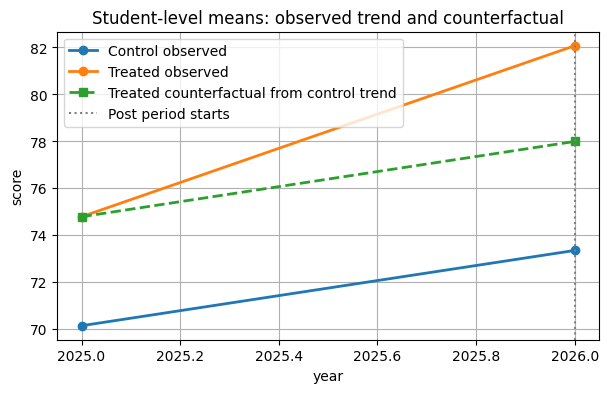

In [4]:
plot_did_counterfactual(
    df,
    "score",
    "year",
    treated_col="treated",
    post_col="post",
    title="Student-level means: observed trend and counterfactual",
)
plt.show()


In [5]:
model = smf.ols("score ~ treated * post", data=df).fit()
model.params


Intercept       70.153869
treated          4.639881
post             3.204524
treated:post     4.074762
dtype: float64

In [6]:
beta_did = model.params["treated:post"]
hand_did = manual_did(df, "score")
print(check_same_estimate(beta_did, hand_did, label="regression and hand DiD"))
print(f"Regression DiD coefficient: {beta_did:.3f}")
print(f"Hand-calculated DiD:       {hand_did:.3f}")


Correct: regression and hand DiD difference is approximately 0.
Regression DiD coefficient: 4.075
Hand-calculated DiD:       4.075


In [7]:
predicted_values_2x2(model)


,treated,post,did,cell,predicted
0,0,0,0,control_pre,70.153869
1,0,1,0,control_post,73.358393
2,1,0,0,treated_pre,74.793750
3,1,1,1,treated_post,82.073036


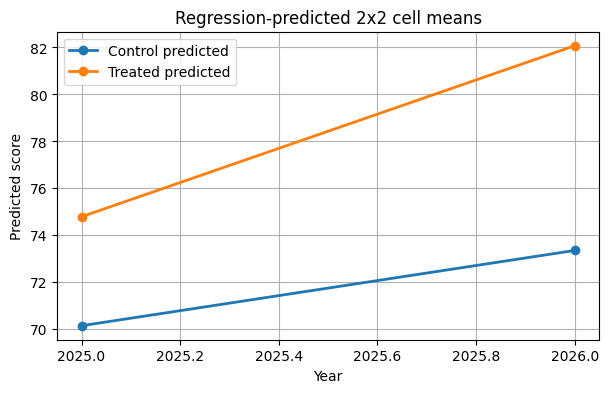

In [8]:
pred = predicted_values_2x2(model).copy()
pred["year"] = pred["post"].map({0: 2025, 1: 2026})

fig, ax = plt.subplots()
for treated_value, part in pred.groupby("treated"):
    label = "Treated predicted" if treated_value == 1 else "Control predicted"
    ax.plot(part["year"], part["predicted"], marker="o", linewidth=2, label=label)
ax.set_xlabel("Year")
ax.set_ylabel("Predicted score")
ax.set_title("Regression-predicted 2x2 cell means")
ax.legend()
plt.show()


## Adding continuous controls

Outcomes and controls can be continuous. The interaction
`treated:post` remains the treatment-effect variable in this
simple setup. For causal work, controls should be measured
before treatment or otherwise plausibly unaffected by the
treatment; post-treatment mediators can become bad controls.


In [9]:
model_controls = smf.ols(
    "score ~ treated * post + attendance + baseline_score",
    data=df,
).fit()

pd.DataFrame(
    {
        "simple_model": model.params,
        "with_controls": model_controls.params,
    }
)


,simple_model,with_controls
Intercept,70.153869,18.062418
attendance,NaN,4.122724
baseline_score,NaN,0.666019
post,3.204524,3.081087
treated,4.639881,3.423138
treated:post,4.074762,4.103940


Takeaway: in a 2x2 design, the coefficient on `treated:post` is
exactly the Difference-in-Differences estimate. It is not a
routine control variable; it is the key treatment variable.
